In [1]:
# -*- coding: utf-8 -*-
"""
Time Series Sales Forecasting with Prophet
============================================
Pipeline:
  1. Load & validate data
  2. EDA — trend plot + stationarity check + decomposition
  3. Statistical test — promo effect (Welch's t-test)
  4. Baseline model — naive seasonal (last-year same-day)
  5. Prophet model — with promo regressor
  6. Evaluation — RMSE / MAE / MAPE on held-out test set
  7. Cross-validation — Prophet diagnostics
  8. 90-day forecast
  9. Visualisations
"""

# ── Imports ────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scipy.stats as stats
import plotly.express as px
import plotly.graph_objects as go
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Config (change these instead of hunting through the code) ──────────────────
CSV_PATH          = 'retail_sales.csv'
FORECAST_HORIZON  = 90          # days to forecast into the future
CV_INITIAL        = '730 days'  # initial training window for cross-validation
CV_PERIOD         = '90 days'   # sliding step for cross-validation
CV_HORIZON        = '90 days'   # CV forecast horizon
TEST_SPLIT_DAYS   = 90          # last N days held out as test set
RANDOM_SEED       = 42
ALPHA             = 0.05        # significance level for hypothesis tests

# ═══════════════════════════════════════════════════════════════════════════════
# 1. LOAD & VALIDATE
# ═══════════════════════════════════════════════════════════════════════════════
df = pd.read_csv(CSV_PATH)
print("── Raw data (first 5 rows) ──")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Dtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

# Parse date
df['date'] = pd.to_datetime(df['date'])

# Sanity check: duplicates on the primary key you care about
dup_count = df.duplicated(subset=['date']).sum() if 'store' not in df.columns \
            else df.duplicated(subset=['date', 'store']).sum()
print(f"\nDuplicate rows on key columns: {dup_count}")

# NOTE: LabelEncoder removed entirely.
# The only categorical processing needed here is ensuring 'promo'
# is numeric (0/1), which it already is in a standard retail dataset.
# If your CSV has string categoricals (e.g. store_type), encode them
# explicitly below using a dict mapping so you can inverse-transform later.
#
# Example (uncomment if needed):
# store_type_map = {v: i for i, v in enumerate(df['store_type'].unique())}
# df['store_type'] = df['store_type'].map(store_type_map)


── Raw data (first 5 rows) ──
         date store_id item_id  sales  price  promo  weekday  month
0  2019-01-01  store_1  item_1     41  21.30      0        1      1
1  2019-01-02  store_1  item_1     53  21.30      0        2      1
2  2019-01-03  store_1  item_1     39  21.30      0        3      1
3  2019-01-04  store_1  item_1     35  21.30      0        4      1
4  2019-01-05  store_1  item_1     51  17.04      1        5      1

Shape: (4565000, 8)
Columns: ['date', 'store_id', 'item_id', 'sales', 'price', 'promo', 'weekday', 'month']
Dtypes:
date         object
store_id     object
item_id      object
sales         int64
price       float64
promo         int64
weekday       int64
month         int64
dtype: object

Missing values:
date        0
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64

Duplicate rows on key columns: 4563174


In [2]:

# ═══════════════════════════════════════════════════════════════════════════════
# 2. EDA
# ═══════════════════════════════════════════════════════════════════════════════

# ── 2a. Daily sales trend ──────────────────────────────────────────────────────
daily_sales = df.groupby('date')['sales'].sum().reset_index()

fig = px.line(daily_sales, x='date', y='sales',
              title='Total Daily Sales Over Time',
              labels={'sales': 'Total Sales', 'date': 'Date'})
fig.show()

# ── 2b. Seasonal decomposition (additive, period = 7 days) ────────────────────
# Helps visually confirm trend, weekly seasonality, and residual noise.
daily_sales_indexed = daily_sales.set_index('date')['sales'].asfreq('D').fillna(method='ffill')

decomposition = seasonal_decompose(daily_sales_indexed, model='additive', period=7)

fig_decomp = go.Figure()
for component, name in zip(
    [decomposition.observed, decomposition.trend,
     decomposition.seasonal, decomposition.resid],
    ['Observed', 'Trend', 'Seasonal', 'Residual']
):
    fig_decomp.add_trace(go.Scatter(x=component.index, y=component.values,
                                    mode='lines', name=name))
fig_decomp.update_layout(title='Seasonal Decomposition (Additive, Period=7)',
                         xaxis_title='Date', yaxis_title='Value')
fig_decomp.show()

# ── 2c. Augmented Dickey-Fuller stationarity test ─────────────────────────────
# ADF tests whether the series has a unit root (non-stationary).
# Prophet handles non-stationarity internally, but documenting this
# shows you understand the data before blindly modelling it.
adf_result = adfuller(daily_sales_indexed.dropna())
print("\n── ADF Stationarity Test ──")
print(f"  ADF Statistic : {adf_result[0]:.4f}")
print(f"  p-value       : {adf_result[1]:.4f}")
print(f"  Critical values: {adf_result[4]}")
if adf_result[1] < ALPHA:
    print("  → Series is STATIONARY (reject unit-root hypothesis).")
else:
    print("  → Series is NON-STATIONARY (fail to reject unit-root hypothesis).")
    print("    Prophet will model the trend component automatically.")



── ADF Stationarity Test ──
  ADF Statistic : -12.1800
  p-value       : 0.0000
  Critical values: {'1%': np.float64(-3.4339881389288407), '5%': np.float64(-2.863147035877915), '10%': np.float64(-2.567625533641975)}
  → Series is STATIONARY (reject unit-root hypothesis).


In [3]:

# ═══════════════════════════════════════════════════════════════════════════════
# 3. STATISTICAL TEST — PROMO EFFECT
# ═══════════════════════════════════════════════════════════════════════════════
sales_no_promo   = df[df['promo'] == 0]['sales'].dropna()
sales_with_promo = df[df['promo'] == 1]['sales'].dropna()

t_stat, p_value = stats.ttest_ind(sales_with_promo, sales_no_promo, equal_var=False)

print("\n── Welch's t-test: Promo Effect ──")
print(f"  Mean sales (no promo)   : {sales_no_promo.mean():.2f}")
print(f"  Mean sales (with promo) : {sales_with_promo.mean():.2f}")
print(f"  T-statistic             : {t_stat:.4f}")
print(f"  P-value                 : {p_value:.4f}")

if p_value < ALPHA:
    print("  → Reject H₀. Promotions have a statistically significant effect on sales.")
else:
    print("  → Fail to reject H₀. No statistically significant promo effect detected.")

# Promo bar chart
fig_promo = go.Figure([
    go.Bar(x=['No Promotion'], y=[sales_no_promo.mean()],
           name='No Promotion',
           text=[f'{sales_no_promo.mean():.2f}'], textposition='auto'),
    go.Bar(x=['With Promotion'], y=[sales_with_promo.mean()],
           name='With Promotion',
           text=[f'{sales_with_promo.mean():.2f}'], textposition='auto'),
])
fig_promo.update_layout(
    title='Average Sales: Promotion vs. No Promotion',
    xaxis_title='Promotion Status',
    yaxis_title='Average Sales',
    barmode='group'
)
fig_promo.show()



── Welch's t-test: Promo Effect ──
  Mean sales (no promo)   : 27.86
  Mean sales (with promo) : 41.86
  T-statistic             : 457.5933
  P-value                 : 0.0000
  → Reject H₀. Promotions have a statistically significant effect on sales.


In [4]:

# ═══════════════════════════════════════════════════════════════════════════════
# 4. PREPARE PROPHET DATAFRAME + TRAIN/TEST SPLIT
# ═══════════════════════════════════════════════════════════════════════════════
prophet_df = (
    df.groupby('date')
      .agg({'sales': 'sum', 'promo': 'mean'})
      .reset_index()
      .rename(columns={'date': 'ds', 'sales': 'y'})
      .sort_values('ds')
      .reset_index(drop=True)
)

print(f"\n── Prophet dataframe ──")
print(prophet_df.head())
print(f"Date range: {prophet_df['ds'].min().date()} → {prophet_df['ds'].max().date()}")
print(f"Total rows: {len(prophet_df)}")

# Temporal train/test split — last TEST_SPLIT_DAYS days held out
cutoff_date = prophet_df['ds'].max() - pd.Timedelta(days=TEST_SPLIT_DAYS)
train_df    = prophet_df[prophet_df['ds'] <= cutoff_date].copy()
test_df     = prophet_df[prophet_df['ds'] >  cutoff_date].copy()

print(f"\nTrain: {len(train_df)} rows  ({train_df['ds'].min().date()} → {train_df['ds'].max().date()})")
print(f"Test : {len(test_df)} rows  ({test_df['ds'].min().date()} → {test_df['ds'].max().date()})")



── Prophet dataframe ──
          ds      y   promo
0 2019-01-01  74119  0.1004
1 2019-01-02  77119  0.0976
2 2019-01-03  70810  0.1080
3 2019-01-04  59269  0.0932
4 2019-01-05  52621  0.1028
Date range: 2019-01-01 → 2023-12-31
Total rows: 1826

Train: 1736 rows  (2019-01-01 → 2023-10-02)
Test : 90 rows  (2023-10-03 → 2023-12-31)


In [5]:

# ═══════════════════════════════════════════════════════════════════════════════
# 5. BASELINE MODEL — NAIVE SEASONAL (last-year same-day)
# ═══════════════════════════════════════════════════════════════════════════════
# A baseline lets you prove Prophet is actually better than a trivial approach.
# Naive seasonal: forecast = value from exactly 364 days ago (52 weeks).

test_df = test_df.copy()
lag_map  = prophet_df.set_index('ds')['y'].to_dict()

test_df['naive_forecast'] = test_df['ds'].apply(
    lambda d: lag_map.get(d - pd.Timedelta(days=364), np.nan)
)
valid_baseline = test_df.dropna(subset=['naive_forecast'])

if len(valid_baseline) > 0:
    baseline_rmse = np.sqrt(mean_squared_error(valid_baseline['y'], valid_baseline['naive_forecast']))
    baseline_mae  = mean_absolute_error(valid_baseline['y'], valid_baseline['naive_forecast'])
    baseline_mape = (np.abs((valid_baseline['y'] - valid_baseline['naive_forecast']) /
                             valid_baseline['y'].replace(0, np.nan)).mean()) * 100
    print(f"\n── Naive Seasonal Baseline (on test set) ──")
    print(f"  RMSE : {baseline_rmse:.2f}")
    print(f"  MAE  : {baseline_mae:.2f}")
    print(f"  MAPE : {baseline_mape:.2f}%")
else:
    print("\nNot enough history for naive seasonal baseline (need ≥ 364 days of training data).")
    baseline_rmse = baseline_mae = baseline_mape = None



── Naive Seasonal Baseline (on test set) ──
  RMSE : 2905.85
  MAE  : 2839.13
  MAPE : 4.24%


In [6]:

# ═══════════════════════════════════════════════════════════════════════════════
# 6. PROPHET MODEL — TRAIN ON TRAIN SET, EVALUATE ON TEST SET
# ═══════════════════════════════════════════════════════════════════════════════
# daily_seasonality=False: data is already at daily granularity (one row per day).
# daily_seasonality=True is only meaningful for sub-daily data.
model = Prophet(
    daily_seasonality=False,   # FIXED: was True — meaningless for daily-level data
    weekly_seasonality=True,
    yearly_seasonality=True,
)
model.add_regressor('promo')
model.fit(train_df)

# Predict on test set
test_forecast = model.predict(test_df[['ds', 'promo']])
test_df = test_df.copy()
test_df['yhat'] = test_forecast['yhat'].values

# ── Test set evaluation ────────────────────────────────────────────────────────
prophet_rmse = np.sqrt(mean_squared_error(test_df['y'], test_df['yhat']))
prophet_mae  = mean_absolute_error(test_df['y'], test_df['yhat'])
prophet_mape = (np.abs((test_df['y'] - test_df['yhat']) /
                        test_df['y'].replace(0, np.nan)).mean()) * 100

print(f"\n── Prophet Model (on test set) ──")
print(f"  RMSE : {prophet_rmse:.2f}")
print(f"  MAE  : {prophet_mae:.2f}")
print(f"  MAPE : {prophet_mape:.2f}%")

if baseline_rmse is not None:
    improvement = ((baseline_rmse - prophet_rmse) / baseline_rmse) * 100
    print(f"\n  Prophet vs Naive Baseline — RMSE improvement: {improvement:.1f}%")

# Actual vs Forecast plot on test set
fig_test = go.Figure()
fig_test.add_trace(go.Scatter(x=test_df['ds'], y=test_df['y'],
                               mode='lines', name='Actual Sales'))
fig_test.add_trace(go.Scatter(x=test_df['ds'], y=test_df['yhat'],
                               mode='lines', name='Prophet Forecast',
                               line=dict(dash='dash')))
fig_test.update_layout(
    title=f'Test Set: Actual vs Prophet Forecast (last {TEST_SPLIT_DAYS} days)',
    xaxis_title='Date', yaxis_title='Sales', hovermode='x unified'
)
fig_test.show()



── Prophet Model (on test set) ──
  RMSE : 1934.42
  MAE  : 1441.01
  MAPE : 2.15%

  Prophet vs Naive Baseline — RMSE improvement: 33.4%


In [7]:

# ═══════════════════════════════════════════════════════════════════════════════
# 7. RETRAIN ON FULL DATA + 90-DAY FUTURE FORECAST
# ═══════════════════════════════════════════════════════════════════════════════
# After evaluation, retrain on ALL available data for the production forecast.
final_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
)
final_model.add_regressor('promo')
final_model.fit(prophet_df)

# Build future dataframe
last_date   = prophet_df['ds'].max()
future_dates = pd.DataFrame({
    'ds': pd.date_range(start=last_date + pd.Timedelta(days=1),
                        periods=FORECAST_HORIZON, freq='D')
})

# ASSUMPTION (documented): future promo rate = historical mean.
# In practice, replace this with the actual planned promo calendar.
mean_promo          = prophet_df['promo'].mean()
future_dates['promo'] = mean_promo
print(f"\nFuture promo assumption: mean historical rate = {mean_promo:.3f}")
print("  → Replace with actual planned promo schedule for production use.")

# Combine history + future, then assign promo values cleanly (FIXED: removed convoluted merge)
full_future           = pd.concat([prophet_df[['ds', 'promo']], future_dates], ignore_index=True)

forecast              = final_model.predict(full_future)

print("\n── Forecast sample (last 5 rows = future) ──")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())



Future promo assumption: mean historical rate = 0.100
  → Replace with actual planned promo schedule for production use.

── Forecast sample (last 5 rows = future) ──
             ds           yhat     yhat_lower     yhat_upper
1911 2024-03-26  115741.166382  112853.001665  118900.613854
1912 2024-03-27  118645.240688  115529.184942  121590.916755
1913 2024-03-28  110769.717501  107770.210138  113826.138688
1914 2024-03-29   98093.793529   94930.514183  101135.066195
1915 2024-03-30   90223.662613   87008.441600   93224.345434


In [8]:

# ═══════════════════════════════════════════════════════════════════════════════
# 8. PROPHET CROSS-VALIDATION
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\nRunning cross-validation (initial={CV_INITIAL}, period={CV_PERIOD}, horizon={CV_HORIZON})...")

df_cv = cross_validation(
    final_model,
    initial=CV_INITIAL,
    period=CV_PERIOD,
    horizon=CV_HORIZON,
    parallel='processes'   # speeds up CV on multi-core machines
)

df_p = performance_metrics(df_cv, metrics=['rmse', 'mae', 'mape'])

print("\n── Cross-Validation Performance Metrics (sample) ──")
print(df_p[['horizon', 'rmse', 'mae', 'mape']].to_string(index=False))

# Summary stats across all horizons
print(f"\n  CV RMSE  — mean: {df_p['rmse'].mean():.2f}  |  max: {df_p['rmse'].max():.2f}")
print(f"  CV MAE   — mean: {df_p['mae'].mean():.2f}  |  max: {df_p['mae'].max():.2f}")
print(f"  CV MAPE  — mean: {df_p['mape'].mean()*100:.2f}%  |  max: {df_p['mape'].max()*100:.2f}%")

# Performance metrics plot
fig_cv = go.Figure()
for metric, label in [('rmse', 'RMSE'), ('mae', 'MAE')]:
    fig_cv.add_trace(go.Scatter(x=df_p['horizon'], y=df_p[metric],
                                 mode='lines+markers', name=label))

# MAPE on secondary axis (different scale)
fig_cv.add_trace(go.Scatter(x=df_p['horizon'], y=df_p['mape'] * 100,
                             mode='lines+markers', name='MAPE (%)',
                             yaxis='y2'))
fig_cv.update_layout(
    title='Prophet CV Performance Metrics Over Forecast Horizon',
    xaxis_title='Horizon (days)',
    yaxis_title='RMSE / MAE',
    yaxis2=dict(title='MAPE (%)', overlaying='y', side='right'),
    hovermode='x unified'
)
fig_cv.show()


INFO:prophet:Making 12 forecasts with cutoffs between 2021-01-15 00:00:00 and 2023-10-02 00:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7a88ec901d90>



Running cross-validation (initial=730 days, period=90 days, horizon=90 days)...

── Cross-Validation Performance Metrics (sample) ──
horizon        rmse         mae     mape
 9 days 2786.536240 2369.135811 0.031144
10 days 2850.496235 2400.361561 0.031203
11 days 2799.686304 2363.283983 0.030964
12 days 2779.325257 2392.369606 0.031561
13 days 2872.897672 2474.234835 0.031940
14 days 2943.175092 2506.789229 0.031872
15 days 2905.531044 2506.605791 0.032425
16 days 2918.334120 2529.374426 0.032958
17 days 2969.533489 2548.825703 0.032940
18 days 2927.410523 2511.541095 0.032611
19 days 2902.911737 2519.323463 0.032935
20 days 3022.676223 2610.222770 0.033457
21 days 3081.205173 2638.217596 0.033401
22 days 3053.573945 2634.292122 0.033828
23 days 3059.668195 2651.546821 0.034342
24 days 3087.135044 2640.577100 0.033948
25 days 3040.920526 2601.825787 0.033634
26 days 3027.846923 2612.532146 0.033906
27 days 3129.829149 2685.551928 0.034297
28 days 3190.905851 2725.126199 0.034457
29 da

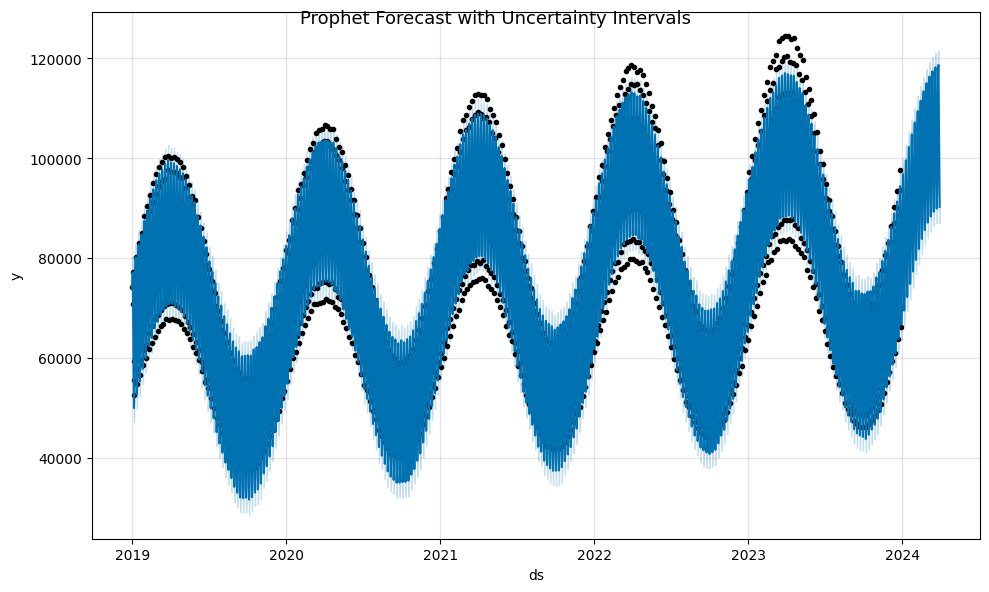

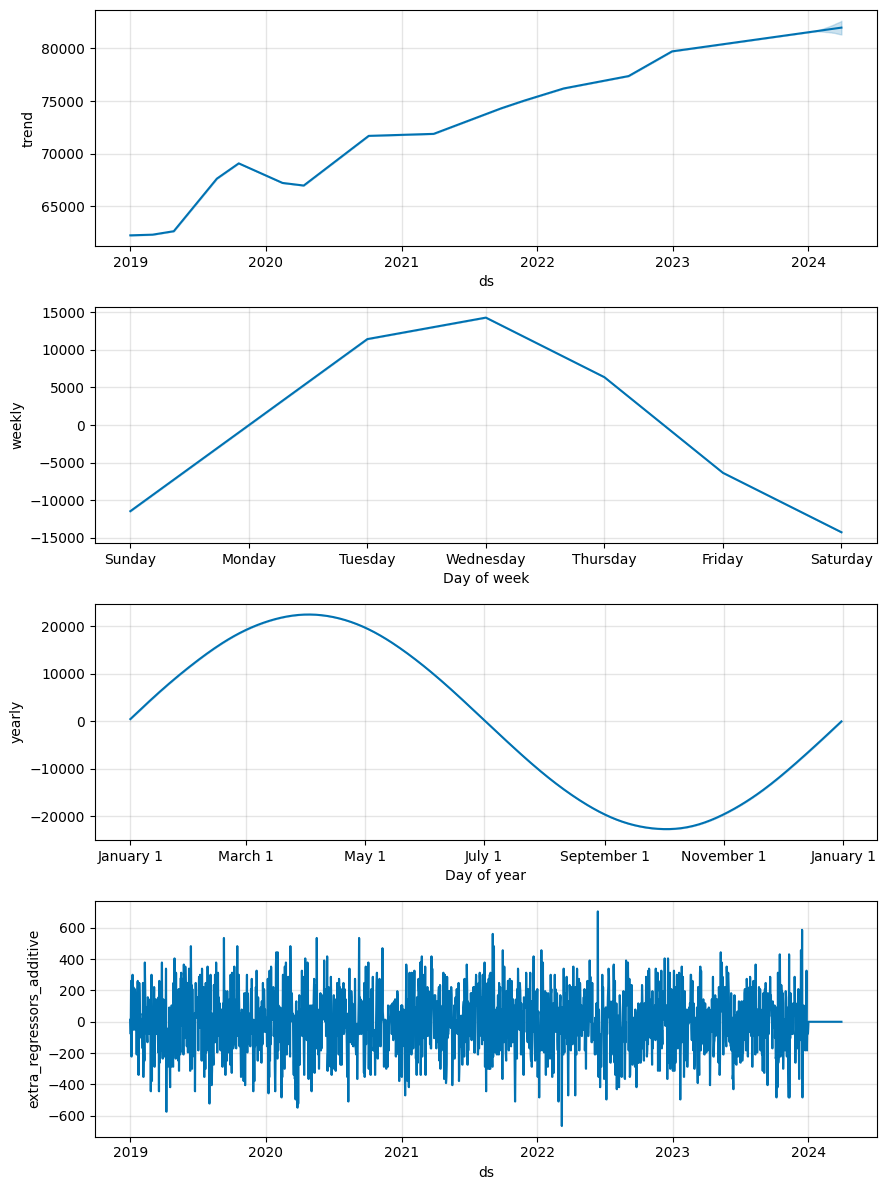

In [11]:

# ═══════════════════════════════════════════════════════════════════════════════
# 9. VISUALISATIONS
# ═══════════════════════════════════════════════════════════════════════════════

# ── 9a. Prophet's built-in forecast plot ──────────────────────────────────────
fig_prophet = final_model.plot(forecast)
fig_prophet.suptitle('Prophet Forecast with Uncertainty Intervals', fontsize=13)
fig_prophet.show()

# ── 9b. Prophet components (trend, weekly, yearly seasonality) ─────────────────
fig_components = final_model.plot_components(forecast)
fig_components.show()

# ── 9c. Actual vs Forecast — full history + future ────────────────────────────
plot_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
plot_df = plot_df.merge(prophet_df[['ds', 'y']].rename(columns={'y': 'Actual Sales'}),
                        on='ds', how='left')

fig_full = go.Figure()
fig_full.add_trace(go.Scatter(x=plot_df['ds'], y=plot_df['Actual Sales'],
                               mode='lines', name='Actual Sales'))
fig_full.add_trace(go.Scatter(x=plot_df['ds'], y=plot_df['yhat'],
                               mode='lines', name='Prophet Forecast',
                               line=dict(dash='dash', color='orange')))
fig_full.add_trace(go.Scatter(
    x=pd.concat([plot_df['ds'], plot_df['ds'][::-1]]),
    y=pd.concat([plot_df['yhat_upper'], plot_df['yhat_lower'][::-1]]),
    fill='toself', fillcolor='rgba(255,165,0,0.15)',
    line=dict(color='rgba(255,255,255,0)'),
    name='Uncertainty Interval', showlegend=True
))
fig_full.add_shape(
    type='line',
    x0=str(last_date), x1=str(last_date),
    y0=0, y1=1,
    xref='x', yref='paper',
    line=dict(dash='dot', color='red', width=1.5)
)

fig_full.add_annotation(
    x=str(last_date),
    y=1,
    xref='x', yref='paper',
    text='Forecast Start',
    showarrow=False,
    xanchor='left',
    font=dict(color='red', size=11)
)


fig_full.update_layout(
    title='Full History + 90-Day Forecast',
    xaxis_title='Date', yaxis_title='Sales', hovermode='x unified'
)
fig_full.show()


In [12]:

# ── 9d. Yearly aggregated comparison ──────────────────────────────────────────
plot_df['year'] = plot_df['ds'].dt.year
yearly_summary = plot_df.groupby('year').agg(
    Actual_Sales=('Actual Sales', 'sum'),
    Prophet_Forecast=('yhat', 'sum')
).reset_index()

fig_yearly = go.Figure()
fig_yearly.add_trace(go.Scatter(x=yearly_summary['year'], y=yearly_summary['Actual_Sales'],
                                 mode='lines+markers', name='Actual Sales'))
fig_yearly.add_trace(go.Scatter(x=yearly_summary['year'], y=yearly_summary['Prophet_Forecast'],
                                 mode='lines+markers', name='Prophet Forecast',
                                 line=dict(dash='dash')))
fig_yearly.update_layout(
    title='Yearly Sales: Actual vs Prophet Forecast',
    xaxis_title='Year', yaxis_title='Total Sales', hovermode='x unified'
)
fig_yearly.show()

# ── Final summary ──────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  FINAL MODEL SUMMARY")
print("="*55)
print(f"  Test set RMSE  : {prophet_rmse:.2f}")
print(f"  Test set MAE   : {prophet_mae:.2f}")
print(f"  Test set MAPE  : {prophet_mape:.2f}%")
if baseline_rmse:
    print(f"  Baseline RMSE  : {baseline_rmse:.2f}")
    print(f"  Improvement    : {improvement:.1f}%")
print(f"  CV RMSE (mean) : {df_p['rmse'].mean():.2f}")
print(f"  CV MAPE (mean) : {df_p['mape'].mean()*100:.2f}%")
print("="*55)


  FINAL MODEL SUMMARY
  Test set RMSE  : 1934.42
  Test set MAE   : 1441.01
  Test set MAPE  : 2.15%
  Baseline RMSE  : 2905.85
  Improvement    : 33.4%
  CV RMSE (mean) : 3483.66
  CV MAPE (mean) : 3.66%
